In [81]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import json
import glob
import random
from google.colab import drive

In [82]:
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Colab Notebooks')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [83]:
CORROSION_BASE = 'Corrosion-dataset'
NOT_LABELLED_PATH = os.path.join(CORROSION_BASE, 'not_labelled')
RUST_PATH = os.path.join(CORROSION_BASE, 'Corrosion', 'rust')
NO_RUST_PATH = os.path.join(CORROSION_BASE, 'Corrosion', 'no_rust')
LOG_IMAGES_PATH = 'log-images'

os.makedirs(RUST_PATH, exist_ok=True)
os.makedirs(NO_RUST_PATH, exist_ok=True)

## DATA LABELLING - CLASS LABELLING

RUST DATASET - Image Level Classification

In [84]:
# Get unlabelled images
unlabelled_images = []
if os.path.exists(NOT_LABELLED_PATH):
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        unlabelled_images.extend(glob.glob(os.path.join(NOT_LABELLED_PATH, ext)))

print(f"\nFound {len(unlabelled_images)} unlabelled images")


Found 686 unlabelled images


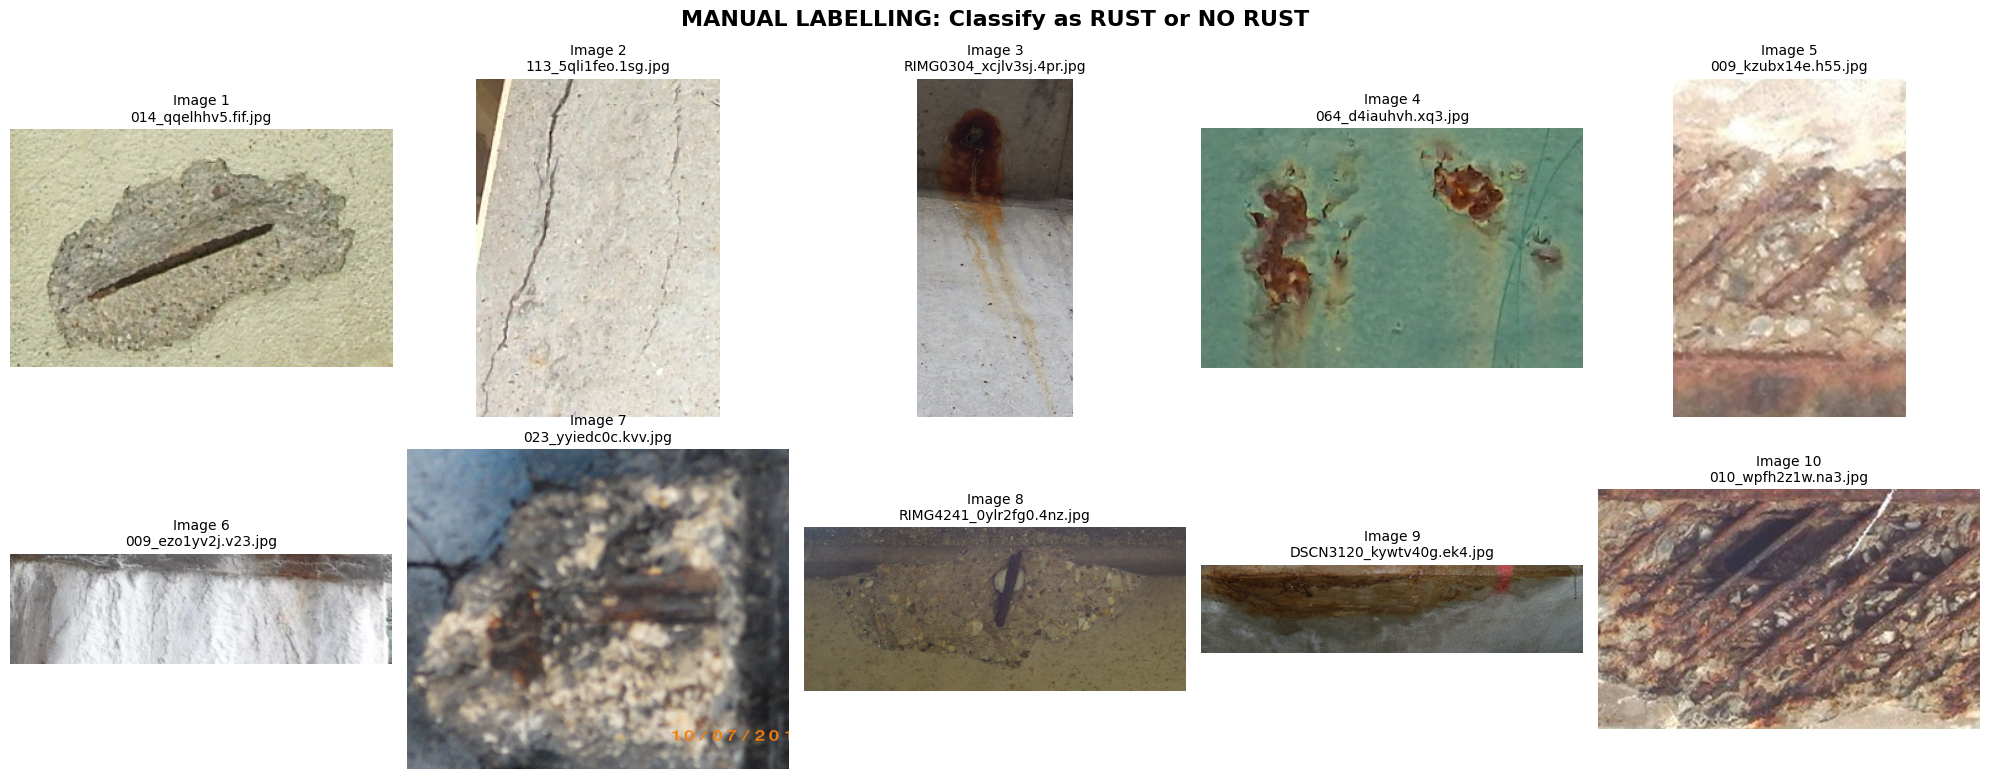


MANUAL TASK: Move 10 images to rust/ or no_rust/ folders


In [85]:
# Display 10 random images for manual labelling
if len(unlabelled_images) >= 10:
    random.shuffle(unlabelled_images)
    sample_images = unlabelled_images[:10]

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle('MANUAL LABELLING: Classify as RUST or NO RUST',
                 fontsize=16, fontweight='bold')

    for i, img_path in enumerate(sample_images):
        ax = axes[i//5, i%5]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f'Image {i+1}\n{os.path.basename(img_path)}', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nMANUAL TASK: Move 10 images to rust/ or no_rust/ folders")

In [86]:
# Verify labelling completion
if os.path.exists(RUST_PATH) and os.path.exists(NO_RUST_PATH):
    rust_count = len(glob.glob(os.path.join(RUST_PATH, '*')))
    no_rust_count = len(glob.glob(os.path.join(NO_RUST_PATH, '*')))
    total = rust_count + no_rust_count

    print(f"\nLabelled images: {total} (Rust: {rust_count}, No rust: {no_rust_count})")

    if total >= 10:
        print("This is Good\n")


Labelled images: 29 (Rust: 14, No rust: 15)
This is Good



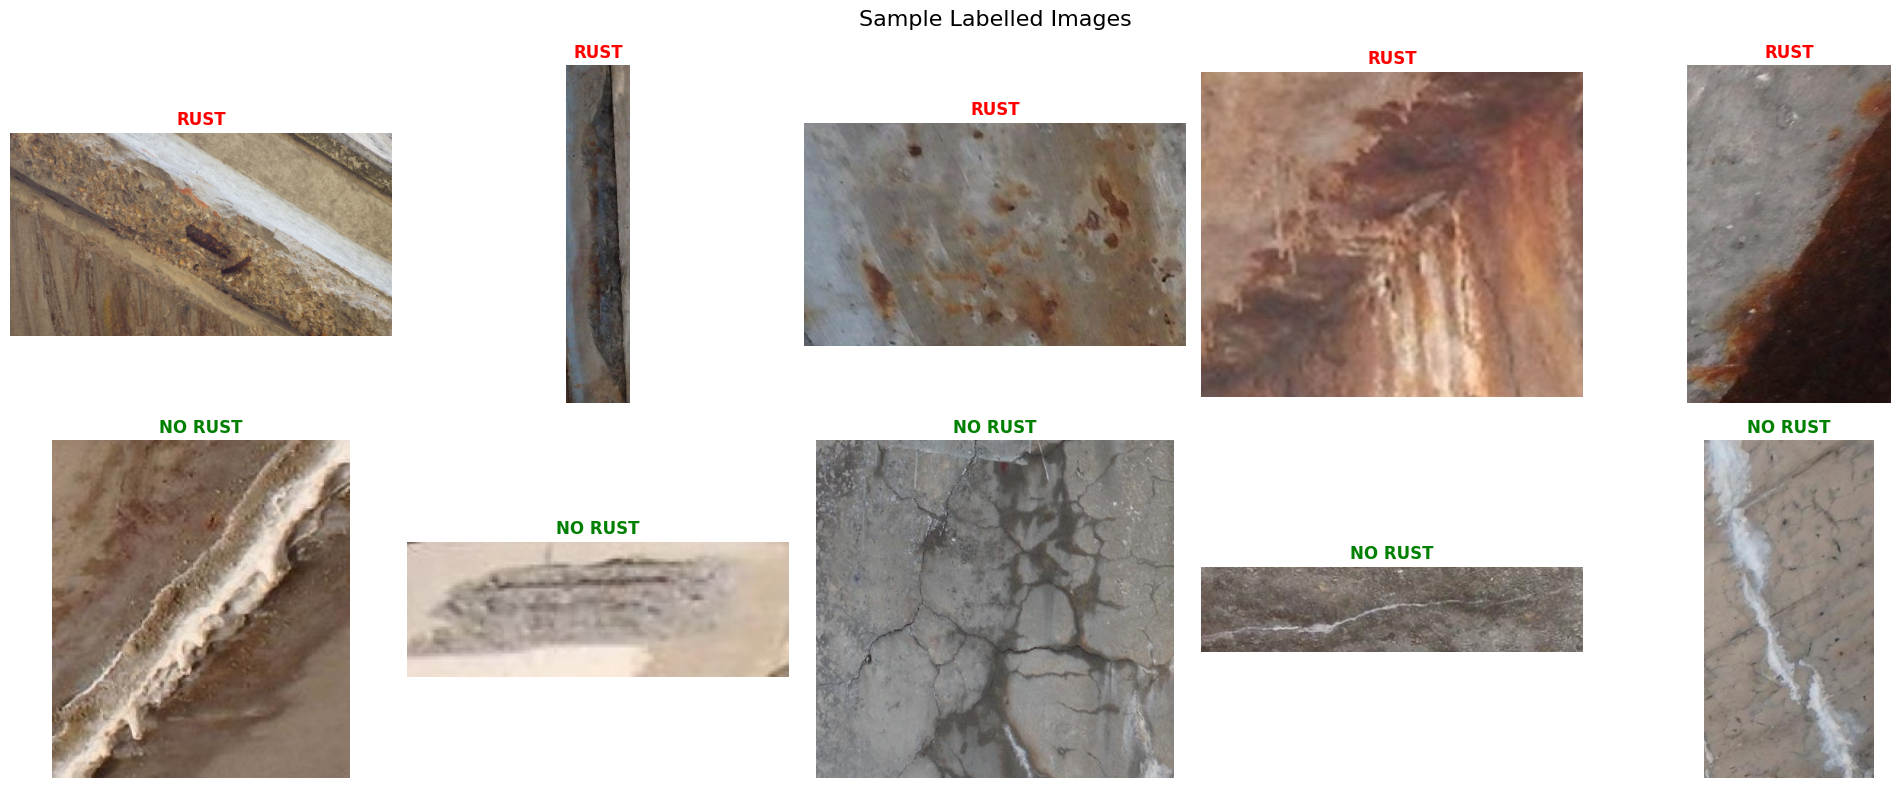

In [87]:
# Display labelled samples
rust_samples = glob.glob(os.path.join(RUST_PATH, '*'))[:5]
no_rust_samples = glob.glob(os.path.join(NO_RUST_PATH, '*'))[:5]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Sample Labelled Images', fontsize=16)

for i in range(5):
    if i < len(rust_samples):
        ax = axes[0, i]
        img = Image.open(rust_samples[i])
        ax.imshow(img)
        ax.set_title('RUST', color='red', fontweight='bold')
        ax.axis('off')

    if i < len(no_rust_samples):
        ax = axes[1, i]
        img = Image.open(no_rust_samples[i])
        ax.imshow(img)
        ax.set_title('NO RUST', color='green', fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.show()

LOG DATASET - Object Level Annotation

In [88]:
log_images = glob.glob(os.path.join(LOG_IMAGES_PATH, 'img_*.png'))
print(f"\nFound {len(log_images)} log images")

if len(log_images) >= 5:
    print("\nLABELME ANNOTATION REQUIRED:")
    print("  1. Install: pip install labelme")
    print("  2. Run: labelme")
    print("  3. Open Dir: log-images")
    print("  4. Create Polygons around wooden logs")
    print("  5. Label as 'log'")
    print("  6. Save and repeat for 5 images")


Found 602 log images

LABELME ANNOTATION REQUIRED:
  1. Install: pip install labelme
  2. Run: labelme
  3. Open Dir: log-images
  4. Create Polygons around wooden logs
  5. Label as 'log'
  6. Save and repeat for 5 images


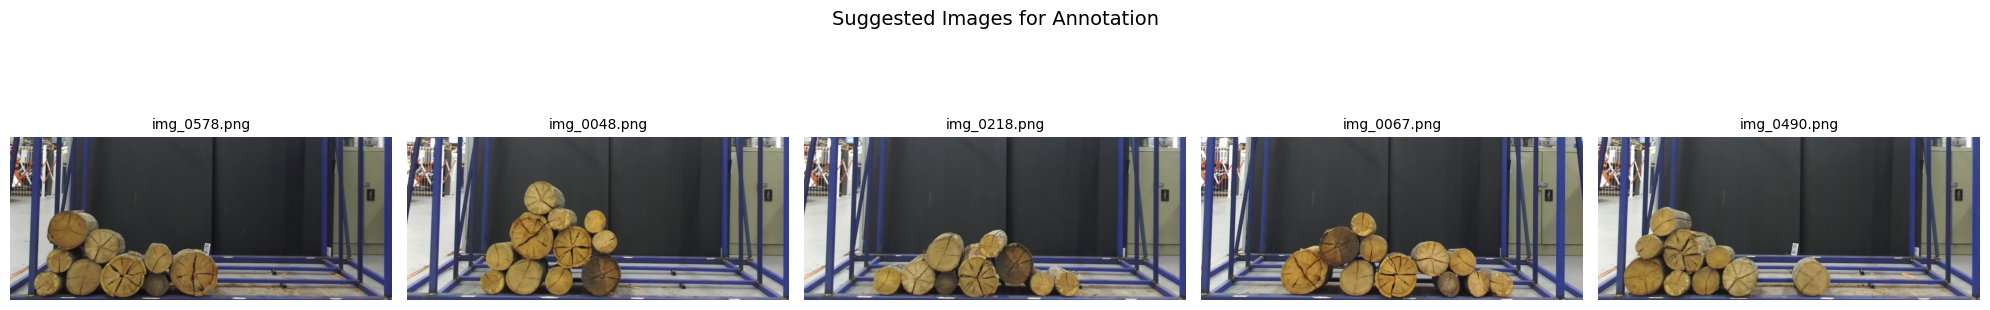

In [89]:
# Display sample images
random.shuffle(log_images)
sample_for_annotation = log_images[:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Suggested Images for Annotation', fontsize=14)

for i, img_path in enumerate(sample_for_annotation):
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(os.path.basename(img_path), fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [90]:
# Check annotation status
json_files = glob.glob(os.path.join(LOG_IMAGES_PATH, '*.json'))
print(f"\nAnnotated: {len(json_files)} images")

if len(json_files) >= 5:
    print("This is Good\n")


Annotated: 5 images
This is Good



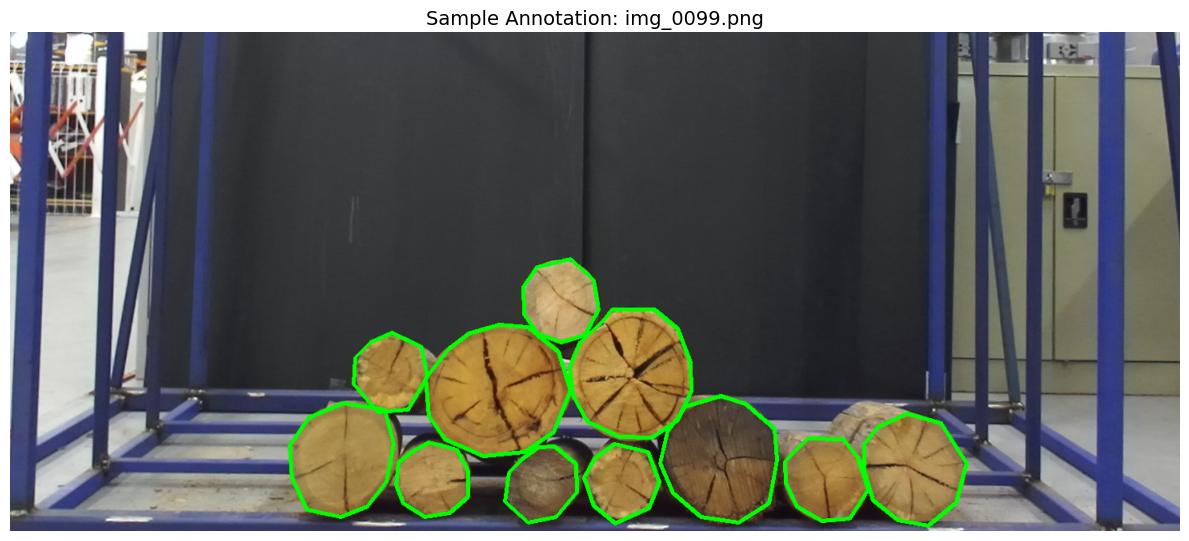

In [91]:
# Visualize one annotation
if json_files:
    with open(json_files[0], 'r') as f:
        annotation = json.load(f)

    img_path = os.path.join(LOG_IMAGES_PATH, annotation['imagePath'])

    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        for shape in annotation['shapes']:
            if shape['shape_type'] == 'polygon':
                points = np.array(shape['points'], dtype=np.int32)
                cv2.polylines(img, [points], True, (0, 255, 0), 3)

        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.title(f'Sample Annotation: {annotation["imagePath"]}', fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("No JSON files found for visualization.")